# Assessing levelling results

In [ ]:
# %load_ext autoreload
# %autoreload 2


import logging

import bordado as bd
import cmocean
import harmonica as hm
import matplotlib.pyplot as plt
import pandas as pd
import plotly.io as pio
import pygmt
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_magnetic_survey`, and the BAS processing steps are repeated in the notebook `processing_AGAP_magnetic_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "mag",
        "mag_microlevelled",
    ]
]

# drop rows with nans
data_df = data_df.dropna(subset=["mag", "mag_microlevelled"], how="any")

# to run faster, limit number of lines
data_df = data_df[~data_df.line.between(133, 142)]
data_df = data_df[~data_df.line.between(168, 176)]
# data_df = data_df[
#     (data_df.line.isin(data_df.line.unique()[::2])) | (data_df.line >= 143)
# ]

data_df

,easting,northing,height,line,unixtime,distance_along_line,mag,mag_microlevelled
2274,1.068728e+06,238284.686698,4162.10,1,1.229508e+09,454910.545217,-23.400,4.190
2275,1.068901e+06,238316.294249,4159.10,1,1.229508e+09,455087.131691,-23.450,4.080
2276,1.069105e+06,238350.576075,4155.00,1,1.229508e+09,455293.529082,-23.405,3.815
2277,1.069311e+06,238385.064023,4149.00,1,1.229508e+09,455502.016399,-23.450,3.620
2278,1.069488e+06,238415.817285,4144.00,1,1.229508e+09,455682.506340,-23.650,3.490
...,...,...,...,...,...,...,...,...
244079,1.605652e+06,538829.512365,2510.80,132,1.231012e+09,342501.172542,-33.130,-24.730
244080,1.605848e+06,538860.754464,2511.35,132,1.231012e+09,342699.565881,-31.315,-23.340
244081,1.606043e+06,538893.039905,2513.70,132,1.231012e+09,342897.090968,-29.410,-21.830
244082,1.606236e+06,538926.185878,2516.05,132,1.231012e+09,343093.093780,-27.630,-20.145


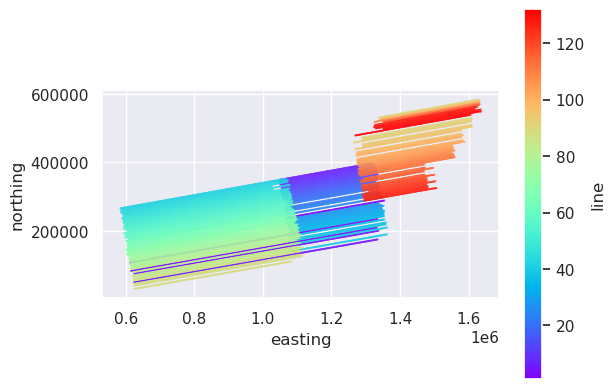

In [3]:
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.1,
    cmap="rainbow",
)
ax.set_aspect("equal")

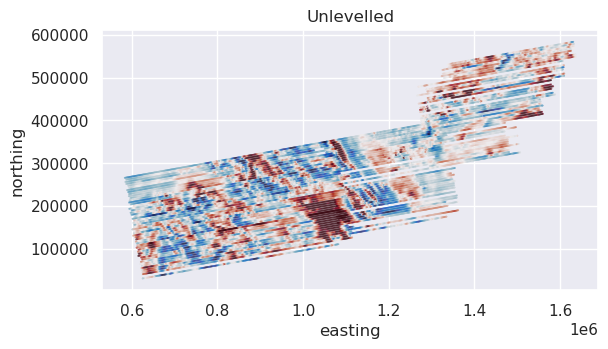

In [4]:
max_abs = vd.maxabs(data_df.mag, percentile=95)
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")

## Grid the pre and post-levelled data

In [5]:
# # block reduce the line data
# data_df_blocked = airbornegeo.block_reduce(
#     data_df,
#     np.median,
#     spacing=1000,
#     reduce_by="distance_along_line",
#     groupby_column="line",
# )
# data_df_blocked = data_df_blocked.dropna(
#     subset=["easting", "northing", "height", "mag"]
# )
# data_df_blocked.describe()

In [ ]:
# coords = (
#     data_df_blocked.easting,
#     data_df_blocked.northing,
#     data_df_blocked.height,
# )
coords = (
    data_df.easting,
    data_df.northing,
    data_df.height,
)
eqs_kwargs = dict(  # noqa: C408
    damping=0.1,
    depth="default",
    block_size=5000,
    window_size=200e3,
    random_state=42,
)
eqs_unlevelled = hm.EquivalentSourcesGB(**eqs_kwargs)
bytes = eqs_unlevelled.estimate_required_memory(coords)
print(f"{bytes / 1e9} GB ram required")

0.566414784 GB ram required


In [12]:
eqs_unlevelled.fit(coords, data_df.mag)

,damping,0.1
,points,None
,depth,'default'
,block_size,5000
,window_size,200000.0
,parallel,True
,random_state,42
,dtype,'float64'


In [27]:
# Define grid coordinates
grid_coords = vd.grid_coordinates(
    region=vd.pad_region(vd.get_region(coords), 10e3),
    spacing=2000,
    extra_coords=4200,  # upward continue
    adjust="region",
)
grid_unlevelled = eqs_unlevelled.grid(grid_coords)

grid_unlevelled = vd.distance_mask(
    (coords[0], coords[1]), maxdist=10e3, grid=grid_unlevelled
)
grid_unlevelled = grid_unlevelled.reset_coords(names="upward").scalars

In [19]:
eqs_levelled = hm.EquivalentSourcesGB(**eqs_kwargs)
eqs_levelled.fit(coords, data_df.mag_microlevelled)

,damping,0.1
,points,None
,depth,'default'
,block_size,5000
,window_size,200000.0
,parallel,True
,random_state,42
,dtype,'float64'


In [26]:
grid_levelled = eqs_levelled.grid(grid_coords)

grid_levelled = vd.distance_mask(
    (coords[0], coords[1]), maxdist=10e3, grid=grid_levelled
)
grid_levelled = grid_levelled.reset_coords(names="upward").scalars

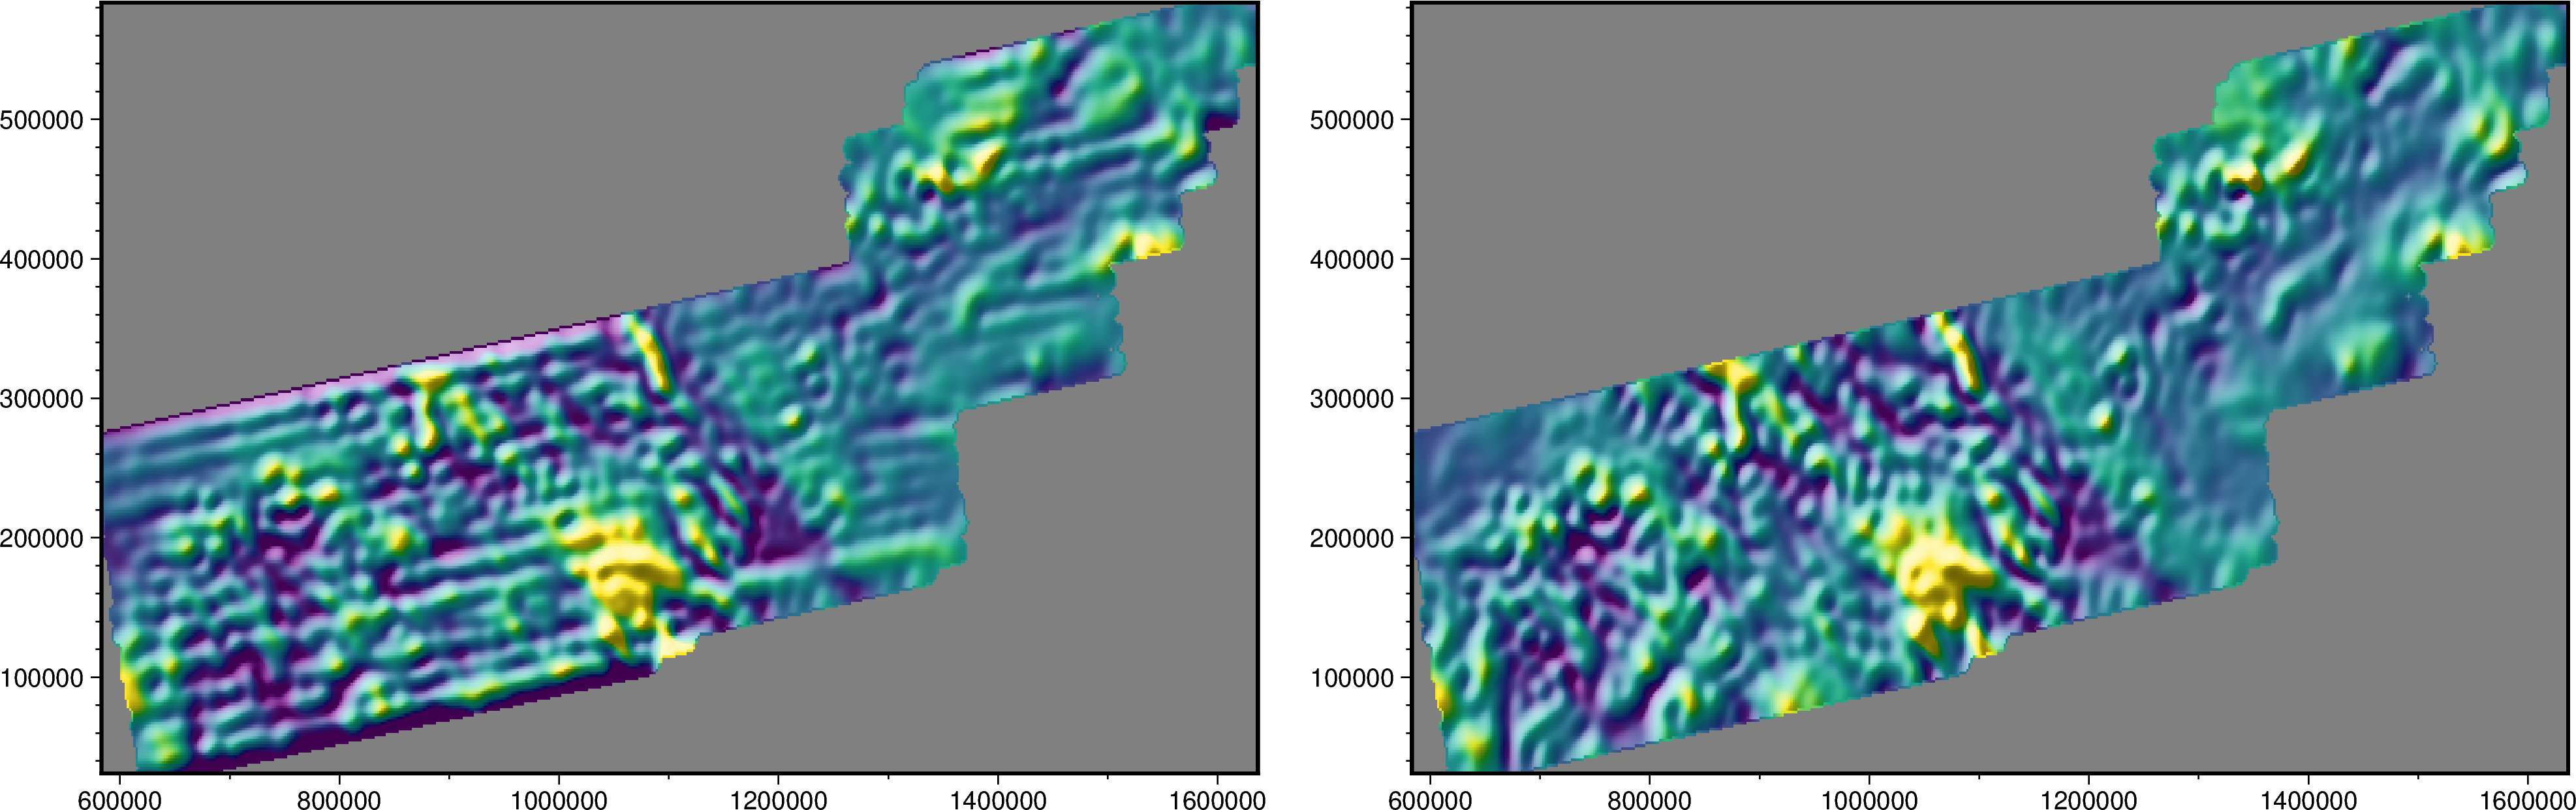

In [33]:
fig = pygmt.Figure()

pygmt.makecpt(
    cmap="viridis",
    series=vd.minmax(
        grid_unlevelled, grid_levelled, min_percentile=2, max_percentile=98
    ),
    background=True,
)

fig.grdimage(
    region=bd.get_region((data_df.easting, data_df.northing)),
    projection="X15c/10c",
    frame=True,
    grid=grid_unlevelled,
    cmap=True,
    shading=True,
)

fig.shift_origin(xshift="w+2c")

fig.grdimage(
    region=bd.get_region((data_df.easting, data_df.northing)),
    projection="X15c/10c",
    frame=True,
    grid=grid_levelled,
    cmap=True,
    shading=True,
)

fig.show()

## Use spatial derivatives to assess levelling performance

In [38]:
hg_unlevelled = airbornegeo.filter_grid(
    grid_unlevelled, filter_type="horizontal_gradient"
)
hg_levelled = airbornegeo.filter_grid(grid_levelled, filter_type="horizontal_gradient")

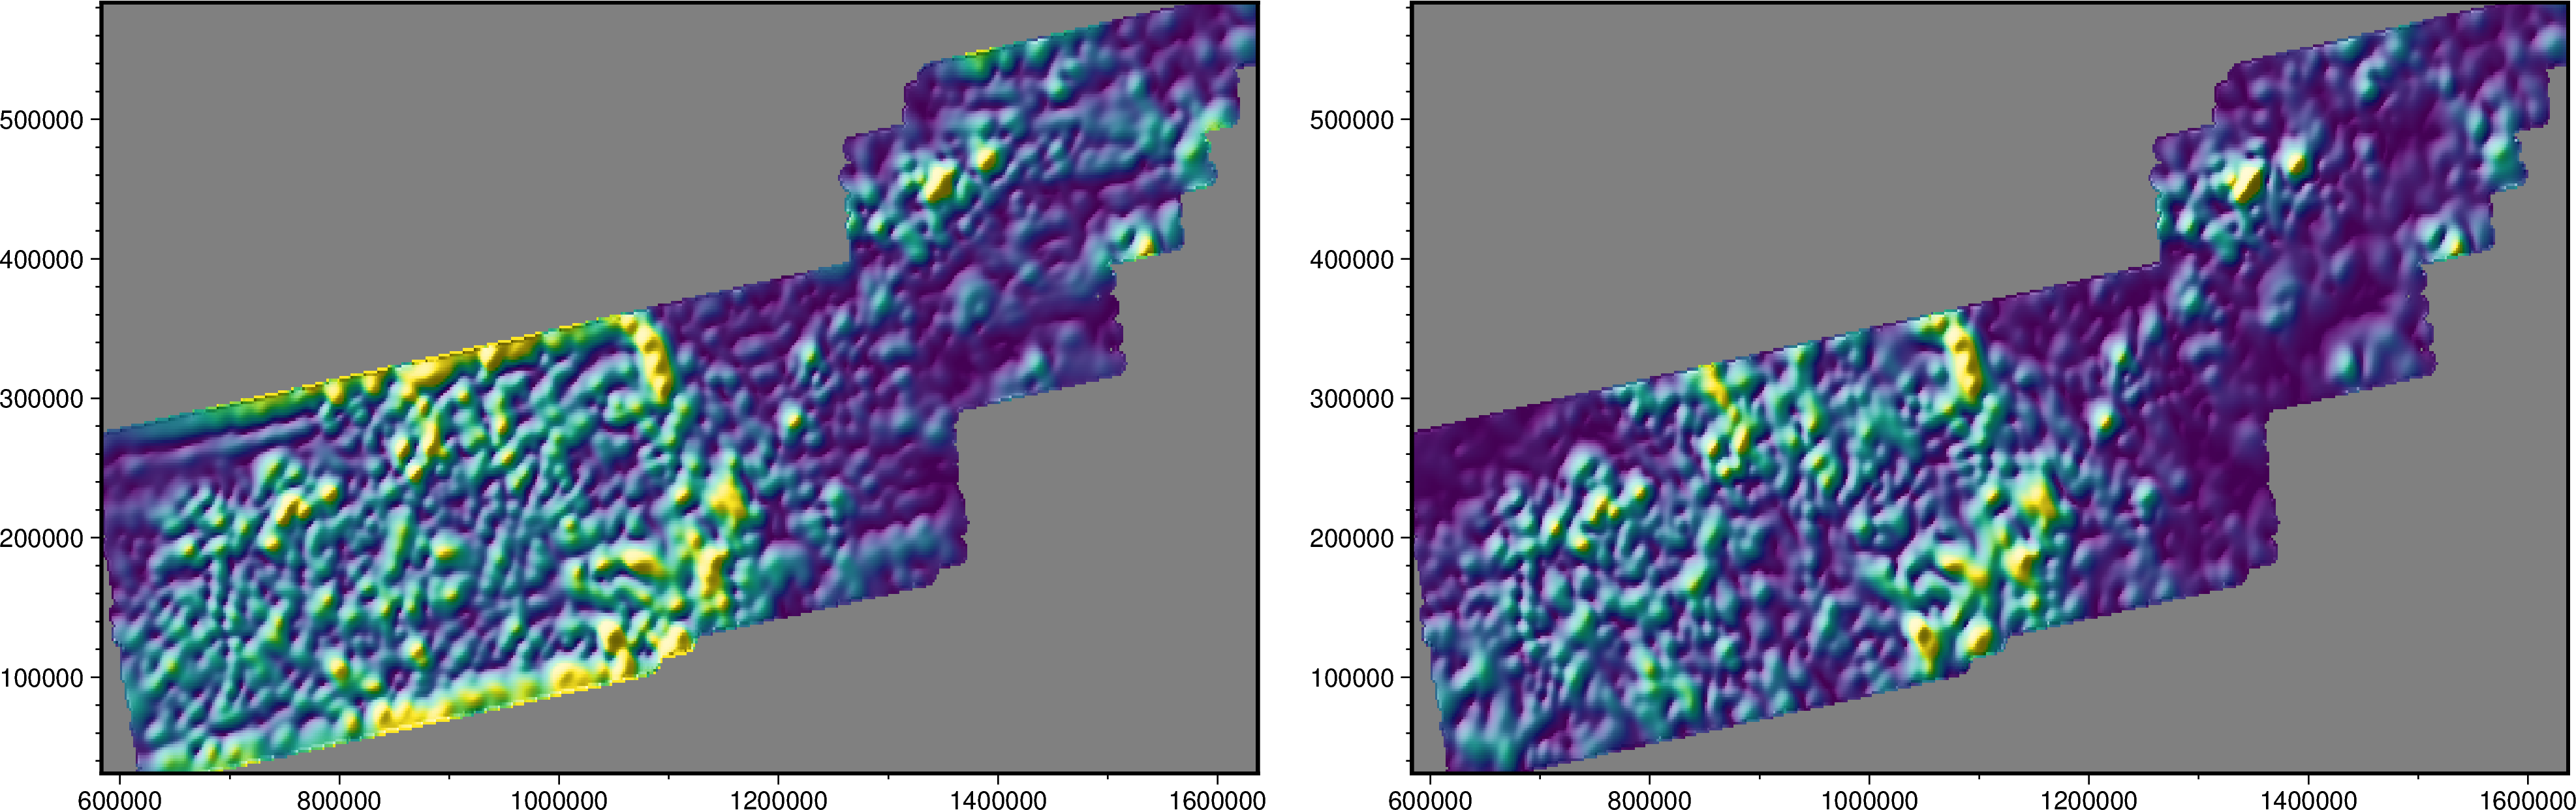

In [37]:
fig = pygmt.Figure()

pygmt.makecpt(
    cmap="viridis",
    series=vd.minmax(hg_unlevelled, hg_levelled, min_percentile=2, max_percentile=98),
    background=True,
)

fig.grdimage(
    region=bd.get_region((data_df.easting, data_df.northing)),
    projection="X15c/10c",
    frame=True,
    grid=hg_unlevelled,
    cmap=True,
    shading=True,
)

fig.shift_origin(xshift="w+2c")

fig.grdimage(
    region=bd.get_region((data_df.easting, data_df.northing)),
    projection="X15c/10c",
    frame=True,
    grid=hg_levelled,
    cmap=True,
    shading=True,
)

fig.show()

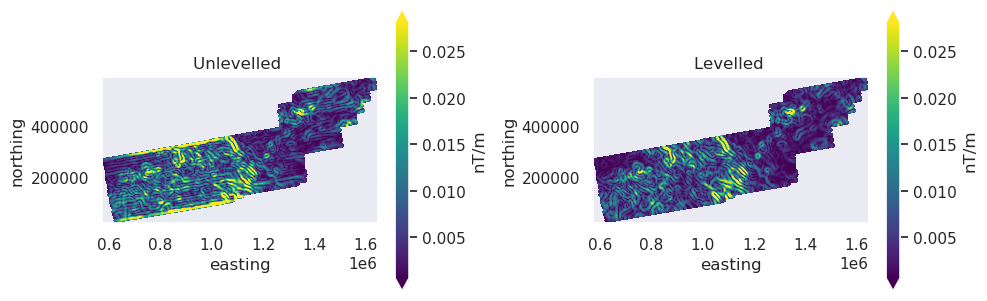

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

vmin, vmax = vd.minmax(hg_unlevelled, hg_levelled, min_percentile=2, max_percentile=98)

hg_unlevelled.plot(
    ax=axs[0],
    cbar_kwargs={
        "shrink": 0.5,
        "label": "nT/m",
    },
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_title("Unlevelled ")
axs[0].set_aspect("equal")

hg_levelled.plot(
    ax=axs[1],
    cbar_kwargs={
        "shrink": 0.5,
        "label": "nT/m",
    },
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_title("Levelled ")
axs[1].set_aspect("equal")

plt.tight_layout()
plt.show()

The above plots show the horizontal gradients for the unlevelled and levelled grids. These highlight the levelling errors in the data. These errors appear to be significantly reduced with the levelling.